In [81]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import statsmodels.api as sm

In [82]:
aa_raw = pd.read_csv("data/AA wind raw.csv")
pema_raw = pd.read_csv("data/pema wind raw.csv")
pha_raw = pd.read_csv("data/pha wind raw.csv")

In [83]:
aa_raw.head()

,code,station,date,latitude,longitude,elev,ws,wd,air_temp,atmos_pres,visibility,dew_point,RH,ceil_hgt
0,997278-99999,"PROVIDENCE, US",2025-01-01 00:00:00,41.807,-71.401,4.0,0.9,80.0,5.90,1011.9,NaN,NaN,NaN,NaN
1,997278-99999,"PROVIDENCE, US",2025-01-01 01:00:00,41.807,-71.401,4.0,2.1,30.0,5.85,1010.5,NaN,NaN,NaN,NaN
2,997278-99999,"PROVIDENCE, US",2025-01-01 02:00:00,41.807,-71.401,4.0,1.5,20.0,4.70,1009.4,NaN,NaN,NaN,NaN
3,997278-99999,"PROVIDENCE, US",2025-01-01 03:00:00,41.807,-71.401,4.0,1.5,70.0,4.30,1008.0,NaN,NaN,NaN,NaN
4,997278-99999,"PROVIDENCE, US",2025-01-01 04:00:00,41.807,-71.401,4.0,1.5,20.0,5.00,1006.4,NaN,NaN,NaN,NaN


In [84]:
pema_raw.head()

,timestamp,id,timestamp_local,sn,rh,temp,lat,lon,device_state,wd,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
0,2025-12-31T23:59:48Z,577612542,2025-12-31T18:59:48Z,MOD-00810,50.5,-2.3,41.8522,-71.4198,ACTIVE,246.5,...,23.652,18.138,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,1.72
1,2025-12-31T23:58:48Z,577610523,2025-12-31T18:58:48Z,MOD-00810,50.2,-2.2,41.8522,-71.4198,ACTIVE,243.9,...,24.142,18.481,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,3.64
2,2025-12-31T23:57:48Z,577610521,2025-12-31T18:57:48Z,MOD-00810,50.3,-2.2,41.8522,-71.4198,ACTIVE,259.8,...,24.126,19.385,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,2.70
3,2025-12-31T23:56:48Z,577610524,2025-12-31T18:56:48Z,MOD-00810,50.0,-2.2,41.8522,-71.4198,ACTIVE,241.9,...,23.334,19.654,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,3.30
4,2025-12-31T23:55:48Z,577610522,2025-12-31T18:55:48Z,MOD-00810,49.8,-2.2,41.8522,-71.4198,ACTIVE,261.7,...,21.268,23.022,16071.0,16072.0,16073.0,18738.0,18739.0,18740.0,18741.0,3.79


In [85]:
pha_raw.head()

,timestamp,id,timestamp_local,sn,rh,temp,lat,lon,device_state,wd,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
0,2025-12-31T23:59:37Z,577610952,2025-12-31T18:59:37Z,MOD-00812,52.7,-2.9,41.8171,-71.4553,ACTIVE,265.2,...,27.697,14.423,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,7.20
1,2025-12-31T23:58:37Z,577610943,2025-12-31T18:58:37Z,MOD-00812,52.3,-2.9,41.8171,-71.4553,ACTIVE,279.0,...,27.339,15.945,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,9.30
2,2025-12-31T23:57:37Z,577610942,2025-12-31T18:57:37Z,MOD-00812,52.3,-2.9,41.8171,-71.4553,ACTIVE,229.1,...,27.759,15.365,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,8.77
3,2025-12-31T23:56:37Z,577610941,2025-12-31T18:56:37Z,MOD-00812,52.6,-2.9,41.8171,-71.4553,ACTIVE,261.5,...,28.132,12.939,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,7.28
4,2025-12-31T23:55:37Z,577608883,2025-12-31T18:55:37Z,MOD-00812,52.7,-2.9,41.8171,-71.4553,ACTIVE,264.2,...,28.955,12.685,16238.0,16239.0,16240.0,18746.0,18747.0,18748.0,18749.0,6.23


In [86]:
aa_raw.columns = aa_raw.columns.str.strip()
columns_to_drop_1 = ["code", "station", "latitude", "longitude", "elev", "air_temp", "atmos_pres", "visibility", "dew_point", "RH", "ceil_hgt"]
aa_raw = aa_raw.drop(columns=columns_to_drop_1)
aa_raw.head()

,date,ws,wd
0,2025-01-01 00:00:00,0.9,80.0
1,2025-01-01 01:00:00,2.1,30.0
2,2025-01-01 02:00:00,1.5,20.0
3,2025-01-01 03:00:00,1.5,70.0
4,2025-01-01 04:00:00,1.5,20.0


In [87]:
aa_raw["datetime_utc"] = pd.to_datetime(aa_raw["date"], utc=True)
aa_raw = aa_raw.drop(columns="date")

theta = np.deg2rad(aa_raw["wd"])

aa_raw["u"] = -aa_raw["ws"] * np.sin(theta)
aa_raw["v"] = -aa_raw["ws"] * np.cos(theta)

cutoff = pd.Timestamp("2025-08-03 00:00:00", tz="UTC")
aa = aa_raw[aa_raw["datetime_utc"] < cutoff]

aa.head()

,ws,wd,datetime_utc,u,v
0,0.9,80.0,2025-01-01 00:00:00+00:00,-0.886327,-0.156283
1,2.1,30.0,2025-01-01 01:00:00+00:00,-1.050000,-1.818653
2,1.5,20.0,2025-01-01 02:00:00+00:00,-0.513030,-1.409539
3,1.5,70.0,2025-01-01 03:00:00+00:00,-1.409539,-0.513030
4,1.5,20.0,2025-01-01 04:00:00+00:00,-0.513030,-1.409539


In [88]:
def preprocess_wind(df, timestamp_col="timestamp", resample_hourly=True):
    df["datetime_utc"] = pd.to_datetime(df[timestamp_col], utc=True)
    theta = np.deg2rad(df["wd"])
    df["u"] = -df["ws"] * np.sin(theta)
    df["v"] = -df["ws"] * np.cos(theta)
    df = df[["ws", "wd", "datetime_utc", "u", "v"]]
    
    cutoff = pd.Timestamp("2025-08-03 00:00:00", tz="UTC")
    df = df[df["datetime_utc"] < cutoff]
    
    if resample_hourly:
        df = df.set_index("datetime_utc").resample("H").mean()
        #need to resample wd and ws based on resampled u-v vectors
        df["ws"] = np.sqrt(df["u"]**2 + df["v"]**2)
        df["wd"] = (np.rad2deg(np.arctan2(-df["u"], -df["v"])) % 360)
        df = df.reset_index()
    
    return df

pema = preprocess_wind(pema_raw)
pha = preprocess_wind(pha_raw)

/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_16275/2054412176.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.set_index("datetime_utc").resample("H").mean()
/var/folders/cv/16s476bd69z2kjqnmm06ls5c0000gn/T/ipykernel_16275/2054412176.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.set_index("datetime_utc").resample("H").mean()


In [89]:
pema.head()

,datetime_utc,ws,wd,u,v
0,2025-01-01 00:00:00+00:00,1.583787,79.793392,-1.558724,-0.280644
1,2025-01-01 01:00:00+00:00,2.148397,51.081698,-1.671544,-1.349648
2,2025-01-01 02:00:00+00:00,1.534606,52.328313,-1.214680,-0.937853
3,2025-01-01 03:00:00+00:00,2.763299,60.500515,-2.405065,-1.360692
4,2025-01-01 04:00:00+00:00,2.691912,49.861663,-2.057940,-1.735301


In [90]:
pha.head()

,datetime_utc,ws,wd,u,v
0,2025-01-01 00:00:00+00:00,0.338424,339.662856,0.117617,-0.317328
1,2025-01-01 01:00:00+00:00,0.951126,329.585189,0.481514,-0.820235
2,2025-01-01 02:00:00+00:00,0.525527,43.771891,-0.363554,-0.379483
3,2025-01-01 03:00:00+00:00,1.351485,60.292604,-1.173856,-0.669756
4,2025-01-01 04:00:00+00:00,1.437000,62.015226,-1.268975,-0.674293


In [91]:
aa["ws"].describe()

count    5041.000000
mean        3.721781
std         2.103636
min         0.000000
25%         2.100000
50%         3.400000
75%         5.000000
max        14.400000
Name: ws, dtype: float64

In [92]:
pema["ws"].describe()

count    4433.000000
mean        3.345591
std         1.916419
min         0.000000
25%         1.903318
50%         3.153349
75%         4.603936
max        13.296856
Name: ws, dtype: float64

In [93]:
pha["ws"].describe()

count    4413.000000
mean        2.354845
std         1.421571
min         0.024252
25%         1.296519
50%         2.123712
75%         3.077276
max        10.452997
Name: ws, dtype: float64

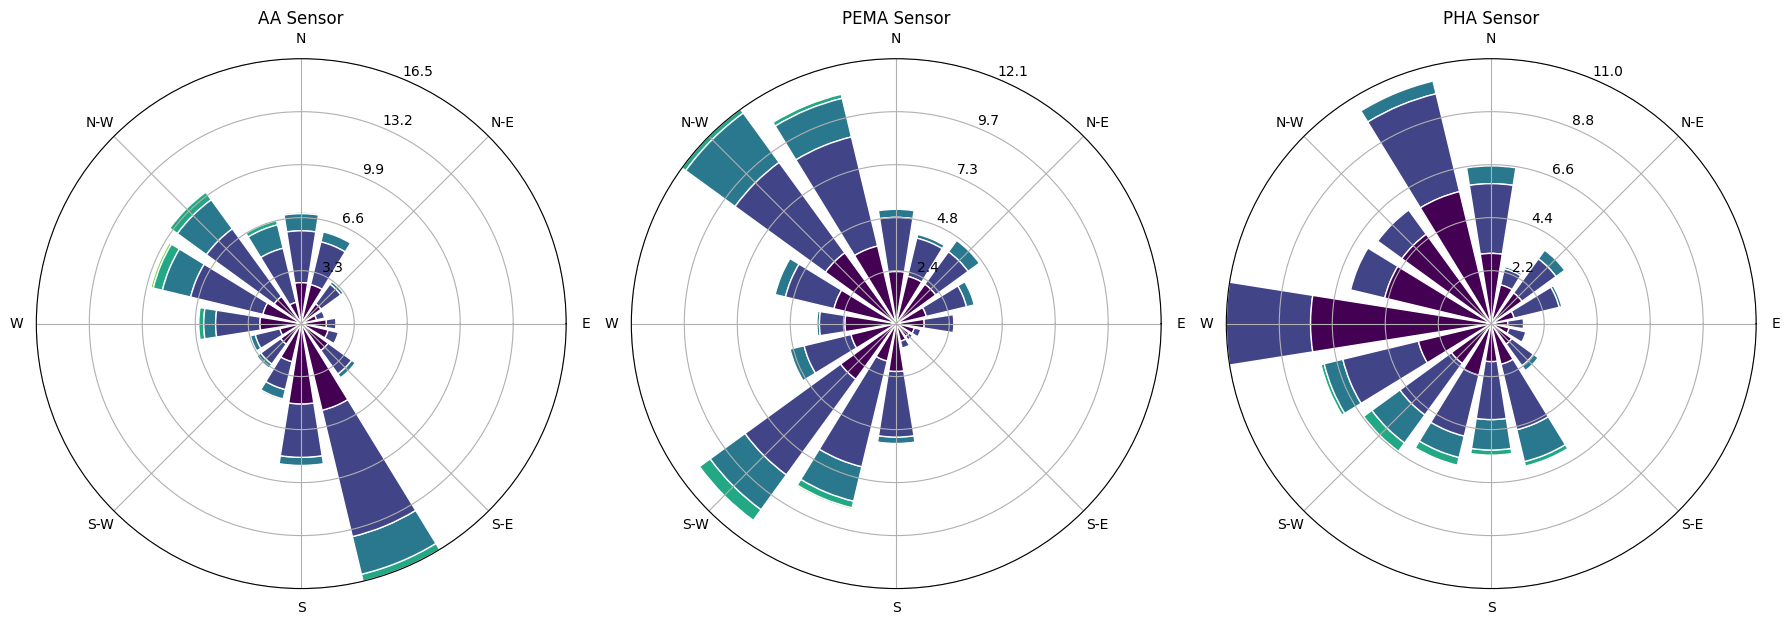

In [94]:
from windrose import WindroseAxes

# prepare the figure with 3 subplots side by side
fig = plt.figure(figsize=(18, 6))

datasets = [aa, pema, pha]
titles = ["AA Sensor", "PEMA Sensor", "PHA Sensor"]

for i, (df, title) in enumerate(zip(datasets, titles), start=1):
    ax = fig.add_subplot(1, 3, i, projection='windrose')
    ax.bar(df["wd"], df["ws"], normed=True, opening=0.8, edgecolor='white')
    ax.set_title(title)
    
plt.tight_layout()
plt.show()

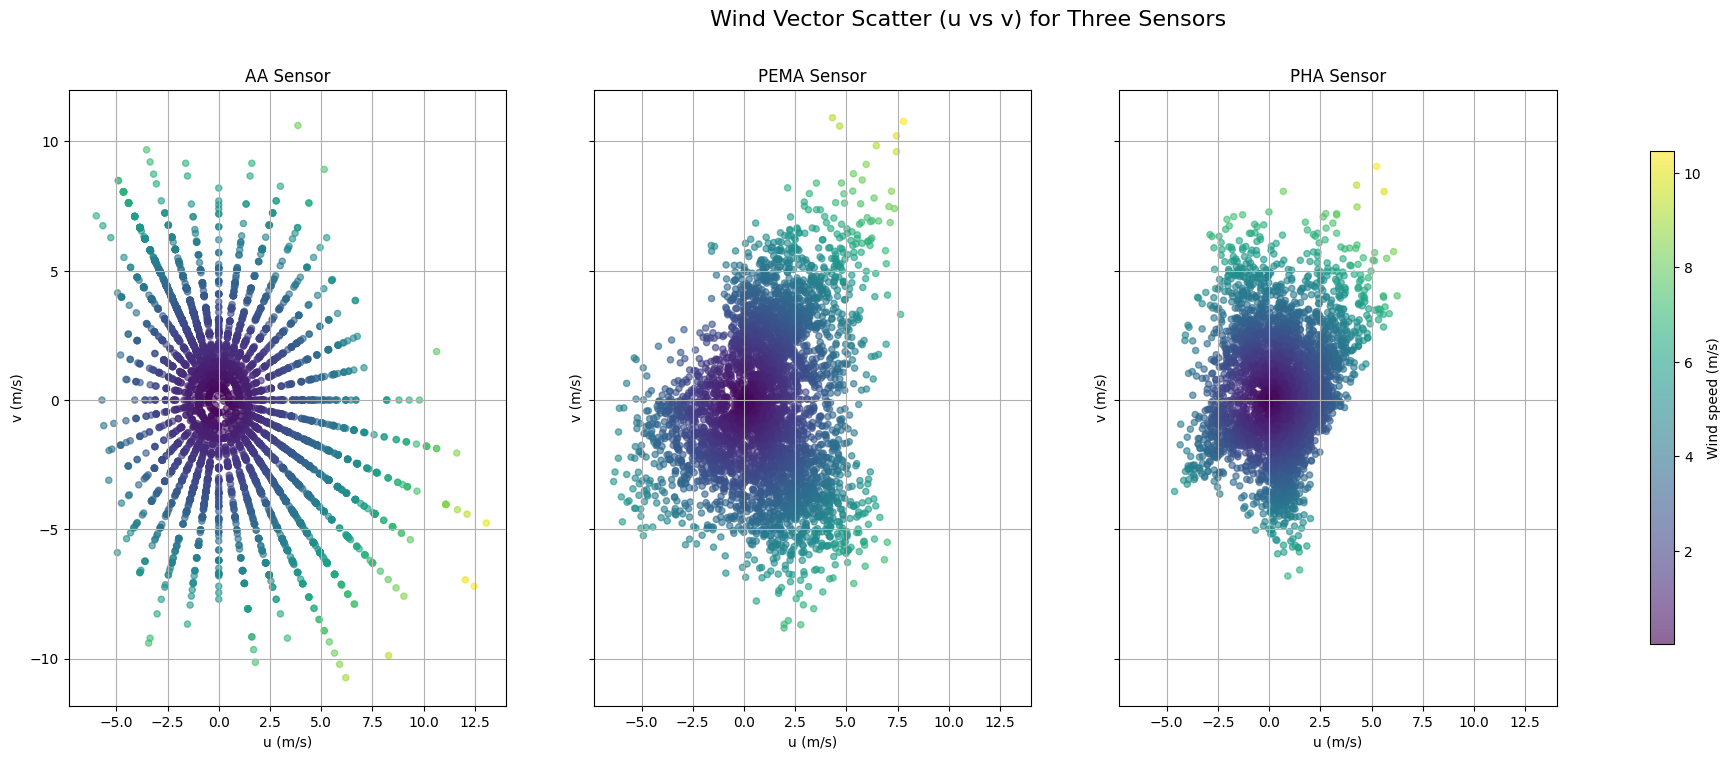

In [97]:
datasets = [aa, pema, pha]
titles = ["AA Sensor", "PEMA Sensor", "PHA Sensor"]

fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharex=True, sharey=True)

for ax, df, title in zip(axes, datasets, titles):
    sc = ax.scatter(df["u"], df["v"], c=np.sqrt(df["u"]**2 + df["v"]**2),
                    cmap="viridis", alpha=0.6, s=20)
    
    ax.set_xlabel("u (m/s)")
    ax.set_ylabel("v (m/s)")
    ax.set_title(title)
    ax.grid(True)
    
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Wind speed (m/s)")

plt.suptitle("Wind Vector Scatter (u vs v) for Three Sensors", fontsize=16)
plt.show()